In [2]:
from google.colab import files

uploaded = files.upload()

Saving stroke_prediction_dataset.csv to stroke_prediction_dataset.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [4]:
import pandas as pd

df = pd.read_csv("stroke_prediction_dataset.csv")

df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


In [5]:
df.shape

(15000, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                15000 non-null  int64  
 1   Patient Name              15000 non-null  object 
 2   Age                       15000 non-null  int64  
 3   Gender                    15000 non-null  object 
 4   Hypertension              15000 non-null  int64  
 5   Heart Disease             15000 non-null  int64  
 6   Marital Status            15000 non-null  object 
 7   Work Type                 15000 non-null  object 
 8   Residence Type            15000 non-null  object 
 9   Average Glucose Level     15000 non-null  float64
 10  Body Mass Index (BMI)     15000 non-null  float64
 11  Smoking Status            15000 non-null  object 
 12  Alcohol Intake            15000 non-null  object 
 13  Physical Activity         15000 non-null  object 
 14  Stroke

## Member 2 - Encoding Categorical Variables

### Introduction

Machine learning algorithms require numerical data for processing.

Therefore, categorical attributes must be converted into numerical values before model development.

Label Encoding was selected to transform categorical variables into numeric form.

In [6]:
df.select_dtypes(include='object').columns

Index(['Patient Name', 'Gender', 'Marital Status', 'Work Type',
       'Residence Type', 'Smoking Status', 'Alcohol Intake',
       'Physical Activity', 'Family History of Stroke', 'Dietary Habits',
       'Blood Pressure Levels', 'Cholesterol Levels', 'Symptoms', 'Diagnosis'],
      dtype='object')

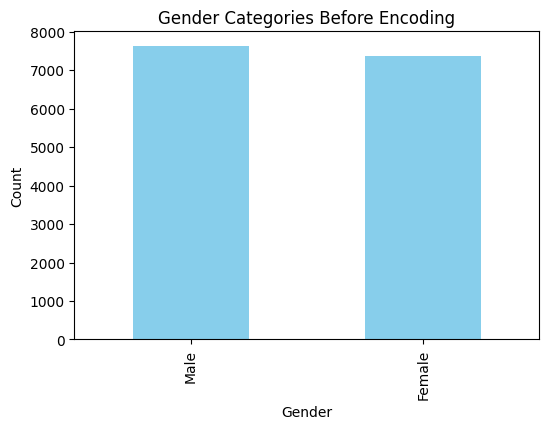

In [7]:
# Visualize one categorical feature before encoding

df['Gender'].value_counts().plot(
    kind='bar',
    color='skyblue',
    figsize=(6,4)
)

plt.title("Gender Categories Before Encoding")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("gender_categories_before_encoding.png")

plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [10]:
categorical_columns = [
    'Gender',
    'Marital Status',
    'Work Type',
    'Residence Type',
    'Smoking Status',
    'Alcohol Intake',
    'Physical Activity',
    'Family History of Stroke',
    'Dietary Habits',
    'Blood Pressure Levels',
    'Cholesterol Levels',
    'Symptoms',
    'Diagnosis'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [7]:
df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,1,0,1,1,3,0,130.91,...,3,2,0,1,5,3.48,1971,4469,1375,1
1,62749,Kaira Subramaniam,80,1,0,0,2,3,1,183.73,...,1,1,0,0,3,1.73,2295,3934,3146,1
2,32145,Dhanush Balan,26,1,1,1,1,1,0,189.00,...,2,0,0,1,3,7.31,2696,3502,4201,1
3,6154,Ivana Baral,73,1,0,0,1,1,1,185.29,...,0,2,0,0,3,5.35,3657,4698,4059,0
4,48973,Darshit Jayaraman,51,1,1,1,0,3,1,177.34,...,2,1,0,1,4,6.84,1068,4169,1150,1


In [11]:
df.select_dtypes(include='object').columns

Index(['Patient Name'], dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                15000 non-null  int64  
 1   Patient Name              15000 non-null  object 
 2   Age                       15000 non-null  int64  
 3   Gender                    15000 non-null  int64  
 4   Hypertension              15000 non-null  int64  
 5   Heart Disease             15000 non-null  int64  
 6   Marital Status            15000 non-null  int64  
 7   Work Type                 15000 non-null  int64  
 8   Residence Type            15000 non-null  int64  
 9   Average Glucose Level     15000 non-null  float64
 10  Body Mass Index (BMI)     15000 non-null  float64
 11  Smoking Status            15000 non-null  int64  
 12  Alcohol Intake            15000 non-null  int64  
 13  Physical Activity         15000 non-null  int64  
 14  Stroke

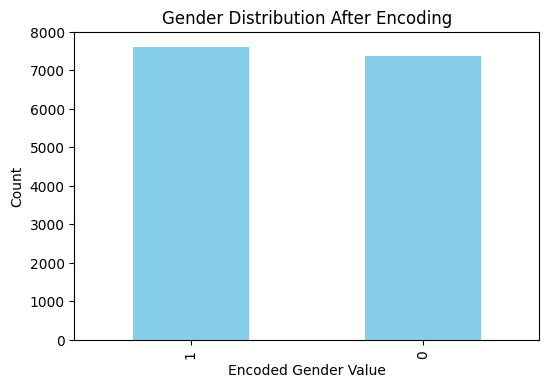

In [13]:
df['Gender'].value_counts().plot(
    kind='bar',
    color='skyblue',
    figsize=(6,4)
)

plt.title("Gender Distribution After Encoding")

plt.xlabel("Encoded Gender Value")
plt.ylabel("Count")

plt.savefig("gender_distribution_after_encoding.png")

plt.show()

## Conclusion

Categorical variables were successfully encoded using Label Encoding.

This transformation converted non-numeric attributes into numerical form, making the dataset suitable for machine learning and predictive analysis.